<a href="https://colab.research.google.com/github/tinemyumi/saude-mental-datasus/blob/main/notebooks/8.diagnostico_internacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Características das internações**

## **Objetivo**
Analisar o perfil diagnóstico das internações em saúde mental (SP, 2015–2025),
o caráter de entrada (eletivo vs. urgência), o tempo de permanência e a mortalidade hospitalar,
comparando os três períodos pandêmicos.

**Autor:** Larissa Tinem

## **1. Setup**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from itertools import combinations

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# ── Paleta e estilo ──
COLOR1 = '#1B4F72'
COLOR2 = '#48C9B0'
COLOR3 = '#5499C7'
PALETTE_PERIODO = {
    'pre-pandemia' : COLOR1,
    'pandemia'     : COLOR2,
    'pos-pandemia' : COLOR3,
}
ORDEM_PERIODOS = ['pre-pandemia', 'pandemia', 'pos-pandemia']

plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

SAVEPATH = '/content/drive/MyDrive/Dataframes/'

## **2. Carregamento e Preparo**

In [4]:
PATH = '/content/drive/MyDrive/Dados/dados_tratados/df_sihsus.parquet'
df = pd.read_parquet(PATH)

print(f'Shape: {df.shape}')
df.head(3)

Shape: (1079670, 26)


,N_AIH,cod_municipio,IDENT,ANO_CMPT,MES_CMPT,NASC,IDADE,SEXO,RACA_COR,ESPEC,...,MUNIC_MOV,CID_ASSO,CID_MORTE,COMPLEX,DT_INTER,DT_SAIDA,QT_DIARIAS,DIAS_PERM,MORTE,periodo_pandemia
0,3514126960003,351880,1,2015,1,1971-10-30,43,3,01,05,...,351880,0000,0000,02,2014-12-28,2014-12-31,3,3,0,pre-pandemia
1,3514126960179,351880,1,2015,1,1972-03-05,42,1,99,05,...,351880,0000,0000,02,2014-12-16,2014-12-20,4,4,0,pre-pandemia
2,3514126960180,351880,1,2015,1,1972-09-25,42,3,99,05,...,351880,0000,0000,02,2014-12-29,2015-01-05,7,7,0,pre-pandemia


In [5]:
#  Decodificações centralizadas

# Dicionário de CIDs relevantes para saúde mental

# Grupos de CID por bloco do capítulo F (para análise agregada)
def classificar_grupo_cid(cid):
    cid = str(cid).strip().upper()

    if cid.startswith('F99'): return 'F99: Transtorno mental não especificado'
    if cid.startswith('F0'): return 'F00–F09: Transtornos mentais orgânicos'
    if cid.startswith('F1'): return 'F10–F19: Transtornos mentais e comportamentais devido ao uso de substâncias psicoativas'
    if cid.startswith('F2'): return 'F20–F29: Esquizofrenia, transtornos esquizotípicos e transtornos delirantes'
    if cid.startswith('F3'): return 'F30–F39: Transtornos do humor (afetivos)'
    if cid.startswith('F4'): return 'F40–F48: Transtornos neuróticos, transtornos relacionados com o “stress” e transtornos somatoformes'
    if cid.startswith('F5'): return 'F50–F59: Síndromes comportamentais associadas a disfunções fisiológicas e a fatores físicos'
    if cid.startswith('F6'): return 'F60–F69: Transtornos da personalidade e do comportamento do adulto'
    if cid.startswith('F7'): return 'F70–F79: Retardo mental'
    if cid.startswith('F8'): return 'F80–F89: Transtornos do desenvolvimento psicológico'
    if cid.startswith('F9'): return 'F90–F98: Transtornos emocionais na infância'
    return 'Outros'

# Padronizar CID
df['DIAG_PRINC'] = df['DIAG_PRINC'].astype(str).str.strip().str.upper()

# Criar grupo CID
df['GRUPO_CID'] = df['DIAG_PRINC'].apply(classificar_grupo_cid)

# Tipo de internação
df['CAR_INT_DESC'] = df['CAR_INT'].map({
    '01': 'Eletivo',
    '02': 'Urgência'
})

# Flag de morte
df['morte_flag'] = df['MORTE'].astype(str).str.strip() == '1'

print('Decodificações aplicadas.')
print(f'Grupos CID encontrados: {df["GRUPO_CID"].nunique()}')

Decodificações aplicadas.
Grupos CID encontrados: 11


## **3. Top CIDs**

### **3.1 Top 10 Geral**

In [6]:
CID_LABELS = {
    'F200': 'Esquizofrenia Paranoide',
    'F192': 'Síndrome de dependência causada pelo uso de múltiplas drogas',
    'F102': 'Síndrome de dependência devido ao uso de álcool',
    'F29':  'Psicose não-orgânica não especificada',
    'F312': 'Transtorno afetivo bipolar (episódio maníaco com sintomas psicóticos)',
    'F205': 'Esquizofrenia Residual',
    'F142': 'Síndrome de dependência devido ao uso da cocaína',
    'F028': 'Demência em outras doenças específicas',
    'F208': 'Outras Esquizofrenias',
    'F068': 'Outros transtornos mentais especificados devido a lesão ou disfunção cerebral'
}

In [7]:
top_grupos = (
    df['GRUPO_CID']
    .value_counts()
    .reset_index()
)

top_grupos.columns = ['GRUPO_CID', 'quantidade']

top_grupos['pct'] = (
    top_grupos['quantidade'] / len(df) * 100
).round(1)

print(top_grupos.to_string(index=False))

                                                                                          GRUPO_CID  quantidade  pct
                        F20–F29: Esquizofrenia, transtornos esquizotípicos e transtornos delirantes      352859 32.7
            F10–F19: Transtornos mentais e comportamentais devido ao uso de substâncias psicoativas      331639 30.7
                                                           F30–F39: Transtornos do humor (afetivos)      169289 15.7
                                                             F00–F09: Transtornos mentais orgânicos      100810  9.3
                                                                            F70–F79: Retardo mental       73478  6.8
                                 F60–F69: Transtornos da personalidade e do comportamento do adulto       26435  2.4
F40–F48: Transtornos neuróticos, transtornos relacionados com o “stress” e transtornos somatoformes       10947  1.0
                                                F80–F89: Transto

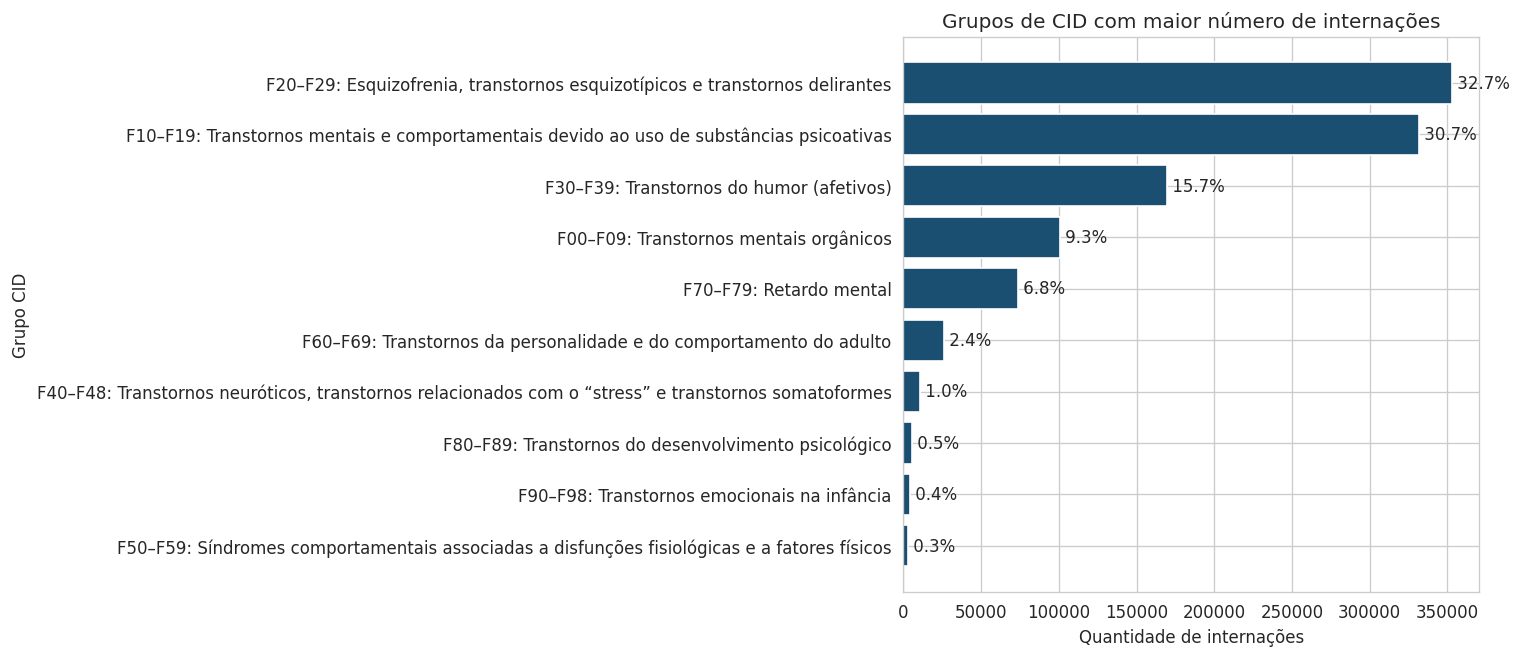

In [8]:
# ==========================================================
# AGRUPAR POR GRUPO_CID
# ==========================================================

top_grupos = (
    df['GRUPO_CID']
    .value_counts()
    .reset_index()
)

top_grupos.columns = ['GRUPO_CID', 'quantidade']

# calcular percentual
top_grupos['pct'] = (
    top_grupos['quantidade'] / len(df) * 100
).round(1)

# pegar top 10 grupos
top_grupos = top_grupos.head(10)

# ==========================================================
# GRÁFICO
# ==========================================================

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    top_grupos['GRUPO_CID'],
    top_grupos['quantidade'],
    color=COLOR1,
    edgecolor='white'
)

ax.invert_yaxis()

# adicionar %
for i, v in enumerate(top_grupos['quantidade']):
    ax.text(v, i, f" {top_grupos['pct'].iloc[i]}%", va='center')

# títulos
ax.set_title('Grupos de CID com maior número de internações')
ax.set_xlabel('Quantidade de internações')
ax.set_ylabel('Grupo CID')

plt.subplots_adjust(left=0.5)
plt.show()

### **3.2 Top 10 por Período**

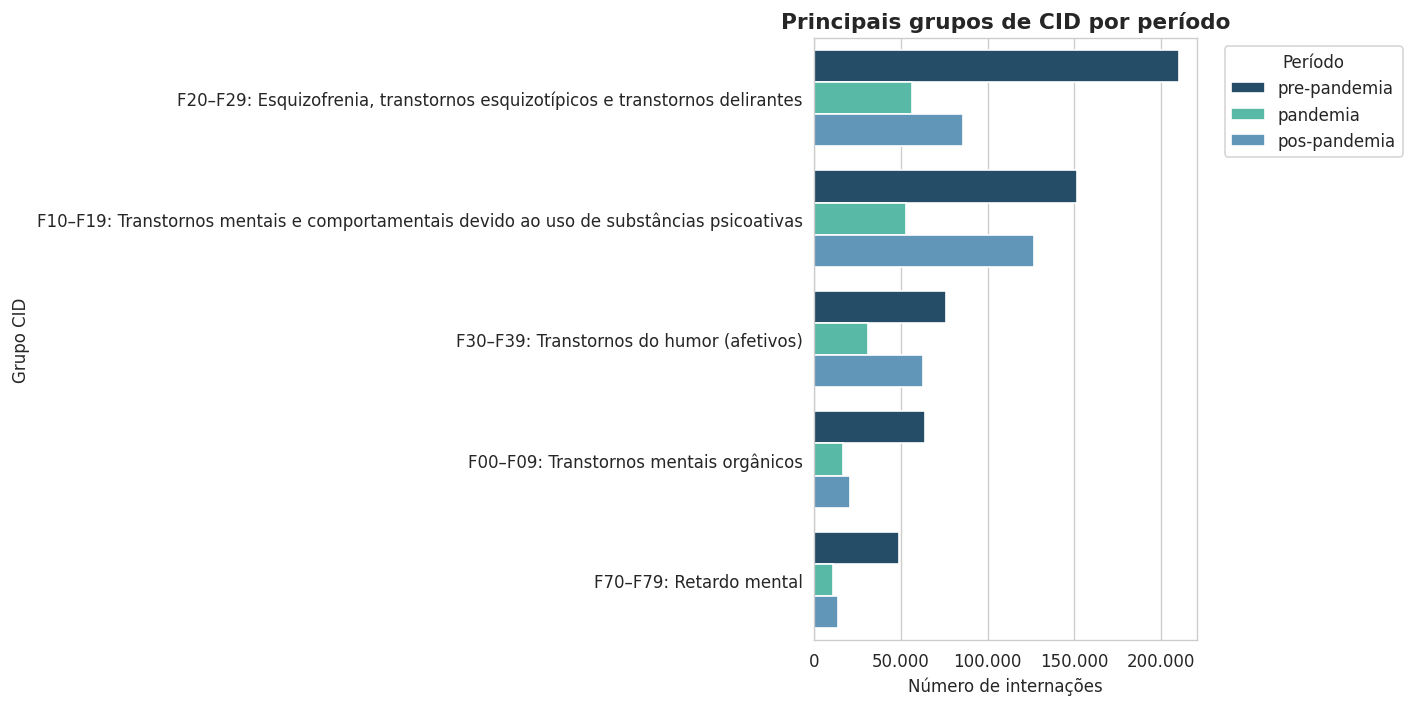

In [9]:
# ==========================================================
# TOP 5 GRUPOS CID POR PERÍODO (GRÁFICO FINAL)
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import pandas as pd

# ----------------------------------------------------------
# 1. Base: top grupos no período completo
# ----------------------------------------------------------

top_grupos = (
    df['GRUPO_CID']
    .value_counts()
    .reset_index()
)

top_grupos.columns = ['GRUPO_CID', 'quantidade']

# pegar top 5
top5_lista = top_grupos.head(5)['GRUPO_CID'].tolist()

# ----------------------------------------------------------
# 2. Contagem por grupo e período
# ----------------------------------------------------------

tabela_grupos = (
    df[df['GRUPO_CID'].isin(top5_lista)]
    .groupby(['GRUPO_CID', 'periodo_pandemia'], observed=True)
    .size()
    .reset_index(name='quantidade')
)

# ----------------------------------------------------------
# 3. Ordenar grupos pelo total geral
# ----------------------------------------------------------

ordem_grupos = (
    tabela_grupos
    .groupby('GRUPO_CID')['quantidade']
    .sum()
    .sort_values(ascending=False)
    .index
    .tolist()
)

tabela_grupos['GRUPO_CID'] = pd.Categorical(
    tabela_grupos['GRUPO_CID'],
    categories=ordem_grupos,
    ordered=True
)

# ----------------------------------------------------------
# 4. Ordenar períodos corretamente
# ----------------------------------------------------------

ordem_periodos = ['pre-pandemia', 'pandemia', 'pos-pandemia']

tabela_grupos['periodo_pandemia'] = pd.Categorical(
    tabela_grupos['periodo_pandemia'],
    categories=ordem_periodos,
    ordered=True
)

# ----------------------------------------------------------
# 5. GRÁFICO
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=tabela_grupos,
    y='GRUPO_CID',
    x='quantidade',
    hue='periodo_pandemia',
    palette=PALETTE_PERIODO,
    ax=ax
)

# títulos
ax.set_title(
    'Principais grupos de CID por período',
    fontsize=13,
    fontweight='bold'
)

ax.set_xlabel('Número de internações')
ax.set_ylabel('Grupo CID')

# formatar eixo X
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.'))
)

# legenda
ax.legend(
    title='Período',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

# ajuste visual
plt.subplots_adjust(left=0.45)
plt.tight_layout()

plt.show()

### **3.3 Mudanças de Ranking entre Períodos**

In [10]:
# ==========================================================
# RANKING DOS GRUPOS CID POR PERÍODO
# ==========================================================

# Garantir que o pandas não corte textos grandes
pd.set_option('display.max_colwidth', None)

# Ordem correta dos períodos
ORDEM_PERIODOS = ['pre-pandemia', 'pandemia', 'pos-pandemia']

df['periodo_pandemia'] = pd.Categorical(
    df['periodo_pandemia'],
    categories=ORDEM_PERIODOS,
    ordered=True
)

# Ranking dos grupos dentro de cada período
ranking_grupos = (
    df
    .groupby(['periodo_pandemia', 'GRUPO_CID'], observed=True)
    .size()
    .reset_index(name='quantidade')
)

# Calcular ranking dentro de cada período
ranking_grupos['rank'] = (
    ranking_grupos
    .groupby('periodo_pandemia', observed=True)['quantidade']
    .rank(ascending=False, method='min')
    .astype(int)
)

# Transformar em tabela
tabela_ranking_grupos = (
    ranking_grupos
    .pivot(
        index='GRUPO_CID',
        columns='periodo_pandemia',
        values='rank'
    )
    .reindex(columns=ORDEM_PERIODOS)
)

# Calcular variação entre pré e pós-pandemia
tabela_ranking_grupos['variação (Pré→Pós)'] = (
    tabela_ranking_grupos['pre-pandemia'] -
    tabela_ranking_grupos['pos-pandemia']
)

# Formatar variação
tabela_ranking_grupos['variação (Pré→Pós)'] = tabela_ranking_grupos['variação (Pré→Pós)'].apply(
    lambda x: f'+{int(x)}' if x > 0 else str(int(x)) if x < 0 else '='
)

print('Ranking dos grupos CID por período (1 = mais frequente):')

print(
    tabela_ranking_grupos
    .sort_values('pre-pandemia')
)

Ranking dos grupos CID por período (1 = mais frequente):
periodo_pandemia                                                                                     pre-pandemia  \
GRUPO_CID                                                                                                           
F20–F29: Esquizofrenia, transtornos esquizotípicos e transtornos delirantes                                     1   
F10–F19: Transtornos mentais e comportamentais devido ao uso de substâncias psicoativas                         2   
F30–F39: Transtornos do humor (afetivos)                                                                        3   
F00–F09: Transtornos mentais orgânicos                                                                          4   
F70–F79: Retardo mental                                                                                         5   
F60–F69: Transtornos da personalidade e do comportamento do adulto                                              6   
F40–F48

### **3.4 Grupos CID (Capítulo F)**

/tmp/ipykernel_59515/2335949103.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabela_prop.groupby('periodo_pandemia')['quantidade'].transform('sum')


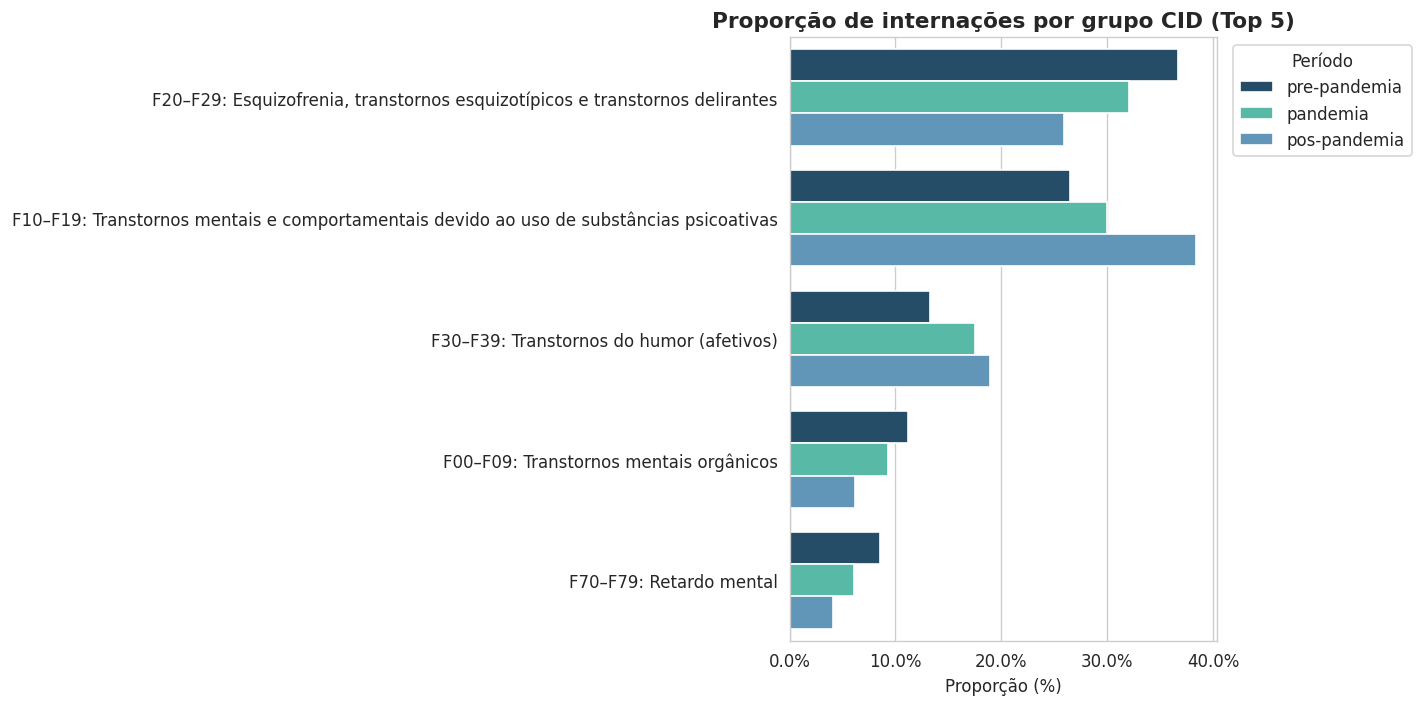

In [43]:
# ==========================================================
# PROPORÇÃO DE INTERNAÇÕES POR GRUPO CID (TOP 5)
# ==========================================================

import seaborn as sns

# tabela base
tabela_prop = (
    df.groupby(['GRUPO_CID', 'periodo_pandemia'], observed=True)
    .size()
    .reset_index(name='quantidade')
)

# proporção dentro do período
tabela_prop['proporcao'] = (
    tabela_prop['quantidade'] /
    tabela_prop.groupby('periodo_pandemia')['quantidade'].transform('sum')
) * 100

# top 5 grupos
top5 = (
    tabela_prop
    .groupby('GRUPO_CID')['quantidade']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

tabela_prop = tabela_prop[tabela_prop['GRUPO_CID'].isin(top5)]

# ordenar grupos
ordem = (
    tabela_prop.groupby('GRUPO_CID')['quantidade']
    .sum()
    .sort_values(ascending=False)
    .index
)

tabela_prop['GRUPO_CID'] = pd.Categorical(
    tabela_prop['GRUPO_CID'],
    categories=ordem,
    ordered=True
)

# ordenar períodos
ordem_periodos = ['pre-pandemia', 'pandemia', 'pos-pandemia']

tabela_prop['periodo_pandemia'] = pd.Categorical(
    tabela_prop['periodo_pandemia'],
    categories=ordem_periodos,
    ordered=True
)

# gráfico
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=tabela_prop,
    y='GRUPO_CID',
    x='proporcao',
    hue='periodo_pandemia',
    palette=PALETTE_PERIODO,
    ax=ax
)

ax.set_title('Proporção de internações por grupo CID (Top 5)', fontsize=13, fontweight='bold')
ax.set_xlabel('Proporção (%)')
ax.set_ylabel('')

ax.xaxis.set_major_formatter(mticker.PercentFormatter())

ax.legend(title='Período', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.subplots_adjust(left=0.45)
plt.tight_layout()

plt.show()

## **4. Eletivo vs. Urgência**

### **4.1 Proporção por Período**


In [12]:
tabela_car = (
    df.groupby(['periodo_pandemia', 'CAR_INT_DESC'], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(ORDEM_PERIODOS)
)
prop_car = tabela_car.div(tabela_car.sum(axis=1), axis=0) * 100
print(prop_car.round(1))

CAR_INT_DESC      Eletivo  Urgência
periodo_pandemia                   
pre-pandemia         44.1      55.9
pandemia             36.5      63.5
pos-pandemia         36.4      63.6


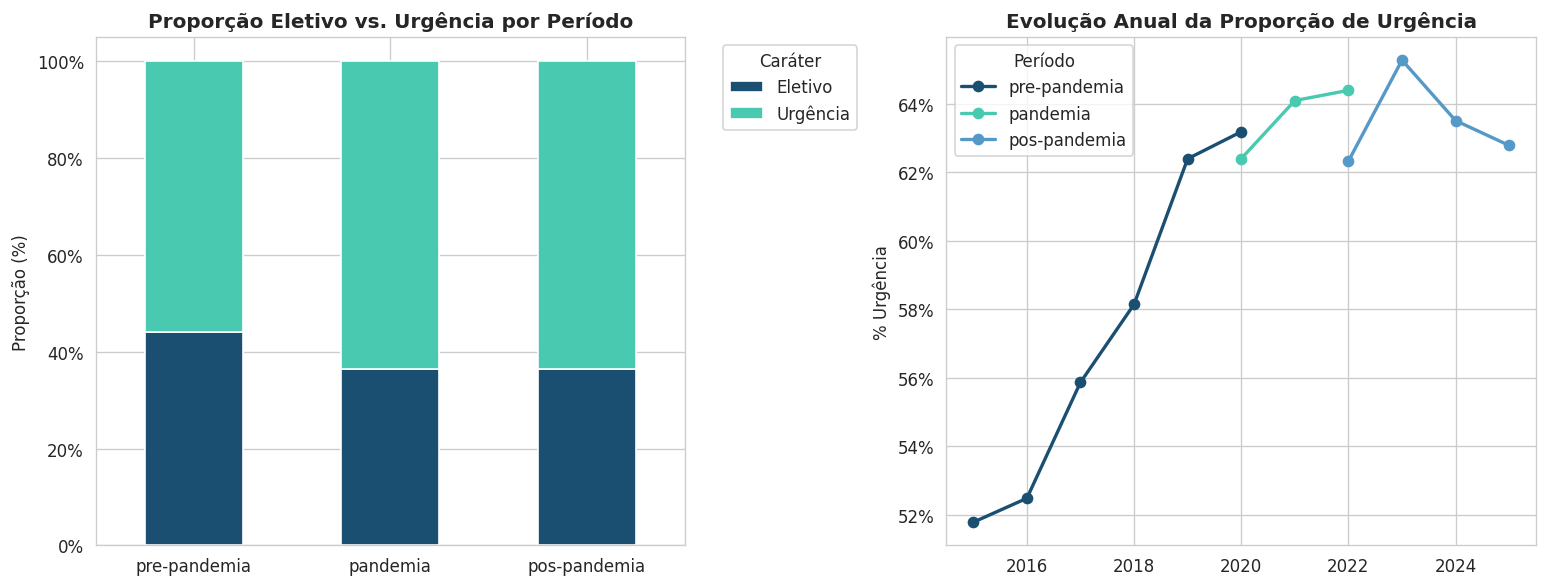

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Barras empilhadas por período ──
prop_car.plot(kind='bar', stacked=True, ax=axes[0],
              color=[COLOR1, COLOR2], edgecolor='white', width=0.5)
axes[0].set_title('Proporção Eletivo vs. Urgência por Período', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Proporção (%)')
axes[0].set_xticklabels(ORDEM_PERIODOS, rotation=0)
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
axes[0].legend(title='Caráter', bbox_to_anchor=(1.05, 1), loc='upper left')

# ── Evolução anual da proporção de urgência ──
pct_urgencia_anual = (
    df.assign(urgencia=df['CAR_INT_DESC'] == 'Urgência')
    .groupby(['ANO_CMPT', 'periodo_pandemia'], observed=True)['urgencia']
    .mean()
    .reset_index(name='pct_urgencia')
)

pct_urgencia_anual['pct_urgencia'] *= 100

for periodo in ORDEM_PERIODOS:
    dados = pct_urgencia_anual[pct_urgencia_anual['periodo_pandemia'] == periodo]
    axes[1].plot(dados['ANO_CMPT'], dados['pct_urgencia'],
                 marker='o', label=periodo,
                 color=PALETTE_PERIODO[periodo], linewidth=2)
axes[1].set_title('Evolução Anual da Proporção de Urgência', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('% Urgência')
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
axes[1].legend(title='Período')

plt.tight_layout()
plt.show()

### **4.2 Caráter de Entrada por Diagnóstico**

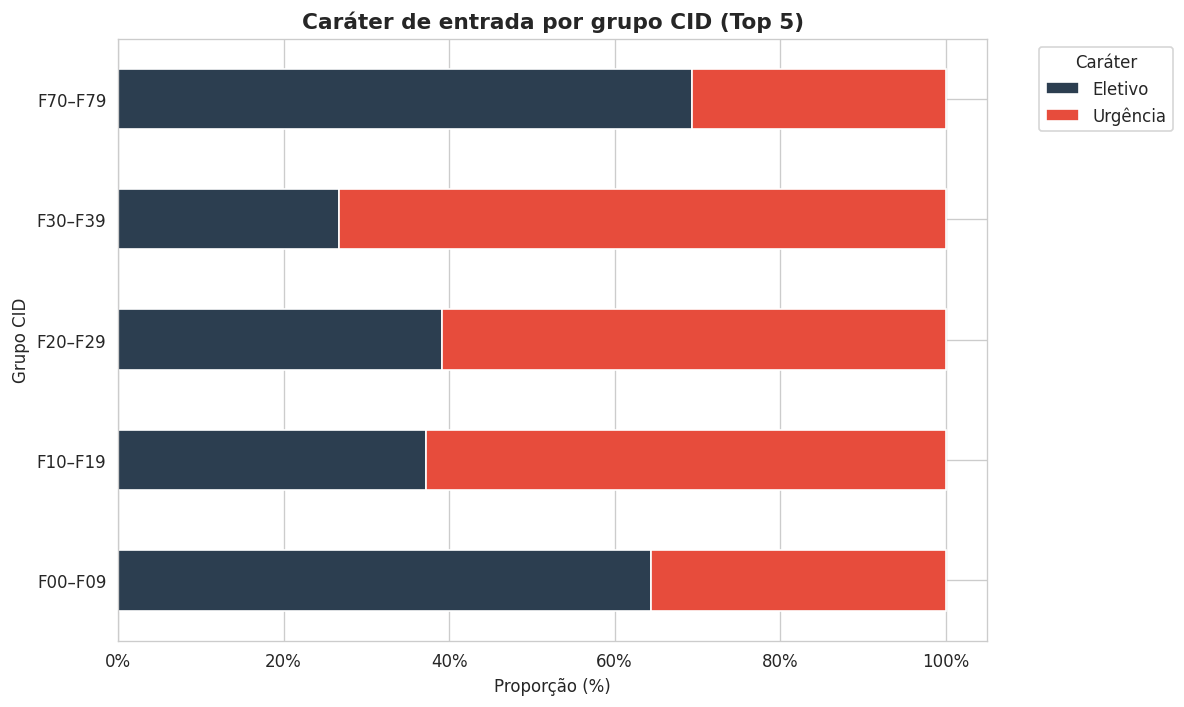

In [41]:
# ==========================================================
# CARÁTER DE ENTRADA POR GRUPO CID (TOP 5)
# ==========================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# TOP 5 grupos
top5_grupos = (
    df['GRUPO_CID']
    .value_counts()
    .head(5)
    .index
)

# tabela
car_por_grupo = (
    df[df['GRUPO_CID'].isin(top5_grupos)]
    .groupby(['GRUPO_CID', 'CAR_INT_DESC'], observed=True)
    .size()
    .unstack(fill_value=0)
)

# proporção (%)
prop_car_grupo = (
    car_por_grupo
    .div(car_por_grupo.sum(axis=1), axis=0) * 100
)

# garantir ordem das colunas
prop_car_grupo = prop_car_grupo[['Eletivo', 'Urgência']]

# encurtar labels (opcional, mas recomendado)
prop_car_grupo.index = [i.split(':')[0] for i in prop_car_grupo.index]

# gráfico
fig, ax = plt.subplots(figsize=(10, 6))

prop_car_grupo.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=['#2C3E50', '#E74C3C'],
    edgecolor='white'
)

ax.set_title('Caráter de entrada por grupo CID (Top 5)', fontsize=13, fontweight='bold')
ax.set_xlabel('Proporção (%)')
ax.set_ylabel('Grupo CID')

ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

ax.legend(title='Caráter', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## **5. Tempo de Permanência**

### **5.1 Distribuição Geral**

> O tempo de permanência tende a ter distribuição muito assimétrica (cauda longa).
> Usamos mediana como medida central e limitamos os gráficos ao percentil 95
> para evitar distorção por outliers extremos.


In [22]:
p95 = df['DIAS_PERM'].quantile(0.95)

print('=== Distribuição geral de DIAS_PERM ==========================')
print(df['DIAS_PERM'].describe().round(1))
print(f'p95 = {p95:.0f} dias (limite dos gráficos)')
print(f'Outliers acima do p95: {(df["DIAS_PERM"] > p95).sum():,} ({(df["DIAS_PERM"] > p95).mean()*100:.1f}%)')

=== Distribuição geral de DIAS_PERM ==========================
count    1079670.0
mean          18.0
std           12.1
min            0.0
25%            6.0
50%           18.0
75%           30.0
max          261.0
Name: DIAS_PERM, dtype: float64
p95 = 31 dias (limite dos gráficos)
Outliers acima do p95: 24,361 (2.3%)


### **5.2 Permanência por Período**

In [23]:
# Estatísticas por período
perm_desc = (
    df.groupby('periodo_pandemia', observed=True)['DIAS_PERM']
    .agg(media='mean', mediana='median', dp='std',
         p25=lambda x: x.quantile(0.25),
         p75=lambda x: x.quantile(0.75))
    .round(1)
)
print(perm_desc)

                  media  mediana    dp  p25   p75
periodo_pandemia                                 
pre-pandemia       19.7     24.0  12.0  7.0  30.0
pandemia           17.2     16.0  11.9  5.0  30.0
pos-pandemia       15.3     13.0  11.7  4.0  29.0


## **6. Mortalidade Hospitalar**

### **6.1 Taxa Geral por Período**


In [26]:
# Taxa de óbito por período
obito_periodo = (
    df.groupby('periodo_pandemia', observed=True)['morte_flag']
    .agg(total='count', obitos='sum')
)
obito_periodo['taxa_%'] = (obito_periodo['obitos'] / obito_periodo['total'] * 100).round(3)
print(obito_periodo)

                   total  obitos  taxa_%
periodo_pandemia                        
pre-pandemia      572775    1644   0.287
pandemia          176312     546   0.310
pos-pandemia      330583     907   0.274


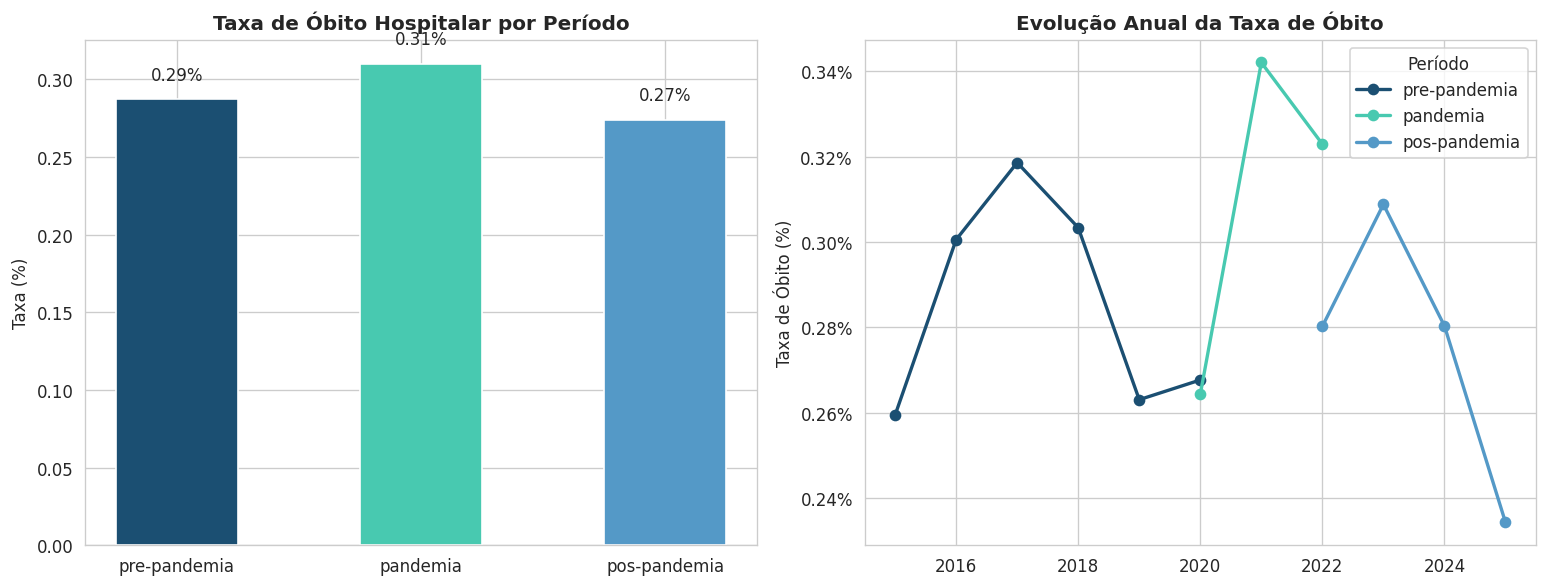

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Taxa por período ──
bars = axes[0].bar(
    ORDEM_PERIODOS, obito_periodo['taxa_%'],
    color=[PALETTE_PERIODO[p] for p in ORDEM_PERIODOS],
    edgecolor='white', width=0.5
)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=10)
axes[0].set_title('Taxa de Óbito Hospitalar por Período', fontweight='bold')
axes[0].set_ylabel('Taxa (%)')
axes[0].set_xlabel('')

# ── Evolução anual da taxa de óbito ──
obito_anual = (
    df.groupby(['ANO_CMPT', 'periodo_pandemia'], observed=True)['morte_flag']
    .mean()
    .reset_index(name='taxa')
)

obito_anual['taxa'] *= 100

for periodo in ORDEM_PERIODOS:
    dados = obito_anual[obito_anual['periodo_pandemia'] == periodo]
    axes[1].plot(dados['ANO_CMPT'], dados['taxa'],
                 marker='o', label=periodo,
                 color=PALETTE_PERIODO[periodo], linewidth=2)
axes[1].set_title('Evolução Anual da Taxa de Óbito', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Taxa de Óbito (%)')
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
axes[1].legend(title='Período')

plt.tight_layout()
plt.show()

### **6.2 Mortalidade por Diagnóstico**

In [31]:
# TAXA DE ÓBITO (%) POR GRUPO CID E PERÍODO

ORDEM_PERIODOS = ['pre-pandemia', 'pandemia', 'pos-pandemia']

# Calcular taxa média de óbito por grupo e período
obito_grupo = (
    df
    .groupby(['GRUPO_CID', 'periodo_pandemia'], observed=True)['morte_flag']
    .mean()
    .unstack()
    .reindex(columns=ORDEM_PERIODOS)
)

# Converter para porcentagem
obito_grupo = obito_grupo * 100

# Ordenar pela taxa de óbito no pré-pandemia
obito_grupo = obito_grupo.sort_values('pre-pandemia', ascending=False)

print('Taxa de óbito (%) por grupo CID e período:')

obito_grupo.round(2)

Taxa de óbito (%) por grupo CID e período:


periodo_pandemia,pre-pandemia,pandemia,pos-pandemia
GRUPO_CID,,,
F99: Transtorno mental não especificado,1.05,1.01,0.66
F50–F59: Síndromes comportamentais associadas a disfunções fisiológicas e a fatores físicos,0.97,0.60,0.54
F00–F09: Transtornos mentais orgânicos,0.64,0.76,1.59
F10–F19: Transtornos mentais e comportamentais devido ao uso de substâncias psicoativas,0.36,0.42,0.24
"F40–F48: Transtornos neuróticos, transtornos relacionados com o “stress” e transtornos somatoformes",0.33,0.16,0.26
F70–F79: Retardo mental,0.22,0.17,0.19
"F20–F29: Esquizofrenia, transtornos esquizotípicos e transtornos delirantes",0.20,0.19,0.19
F90–F98: Transtornos emocionais na infância,0.17,0.41,0.23
F30–F39: Transtornos do humor (afetivos),0.13,0.17,0.09


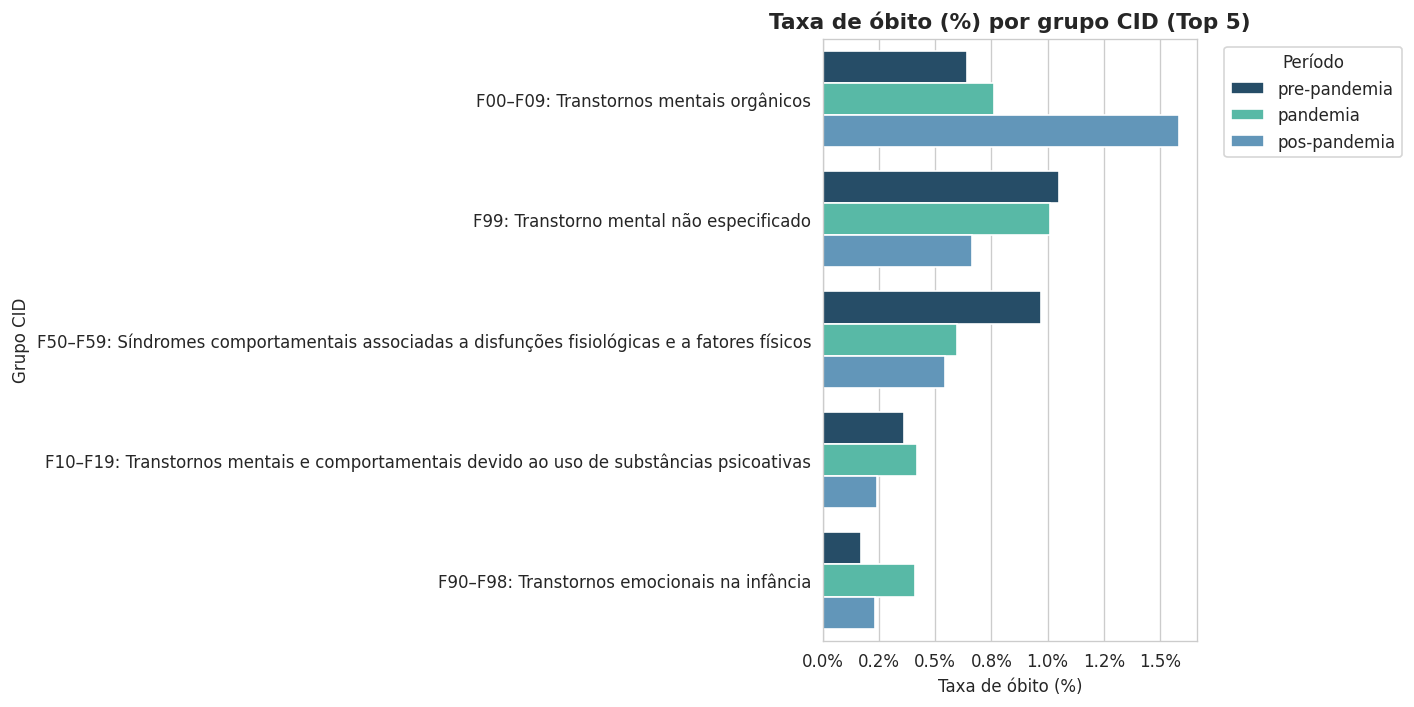

In [45]:
# ==========================================================
# TAXA DE ÓBITO (%) POR GRUPO CID (TOP 5)
# ==========================================================

# garantir flag correta
df['morte_flag'] = df['MORTE'].astype(str).str.strip() == '1'

# taxa de óbito
obito_grupo = (
    df.groupby(['GRUPO_CID', 'periodo_pandemia'], observed=True)['morte_flag']
    .mean()
    .reset_index(name='taxa_obito')
)

obito_grupo['taxa_obito'] *= 100

# top 5 grupos
top5 = (
    obito_grupo.groupby('GRUPO_CID')['taxa_obito']
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

obito_grupo = obito_grupo[obito_grupo['GRUPO_CID'].isin(top5)]

# ordenar grupos
ordem = (
    obito_grupo.groupby('GRUPO_CID')['taxa_obito']
    .mean()
    .sort_values(ascending=False)
    .index
)

obito_grupo['GRUPO_CID'] = pd.Categorical(
    obito_grupo['GRUPO_CID'],
    categories=ordem,
    ordered=True
)

# ordenar períodos
ordem_periodos = ['pre-pandemia', 'pandemia', 'pos-pandemia']

obito_grupo['periodo_pandemia'] = pd.Categorical(
    obito_grupo['periodo_pandemia'],
    categories=ordem_periodos,
    ordered=True
)

# gráfico
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=obito_grupo,
    y='GRUPO_CID',
    x='taxa_obito',
    hue='periodo_pandemia',
    palette=PALETTE_PERIODO,
    ax=ax
)

ax.set_title('Taxa de óbito (%) por grupo CID (Top 5)', fontsize=13, fontweight='bold')
ax.set_xlabel('Taxa de óbito (%)')
ax.set_ylabel('Grupo CID')

ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

ax.legend(title='Período', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.subplots_adjust(left=0.45)
plt.tight_layout()

plt.show()

### **6.3 Mortalidade por Perfil Sociodemográfico**

In [35]:
# Decodificações necessárias
df['SEXO_DESC'] = df['SEXO'].map({
    '1': 'Masculino',
    '3': 'Feminino'
})

df['FAIXA_ETARIA'] = pd.cut(
    df['IDADE'],
    bins=[0, 17, 29, 44, 59, 120],
    labels=['0–17', '18–29', '30–44', '45–59', '60+']
)

# ── Taxa de óbito por sexo e período ──
obito_sexo = (
    df.groupby(['periodo_pandemia', 'SEXO_DESC'], observed=True)['morte_flag']
    .mean()
    .unstack()
    .reindex(ORDEM_PERIODOS)
)

obito_sexo = (obito_sexo * 100).round(2)

print('=== Taxa de óbito por Sexo e Período (%) ====================')
print(obito_sexo)


# ── Taxa de óbito por faixa etária e período ──
obito_faixa = (
    df.groupby(['periodo_pandemia', 'FAIXA_ETARIA'], observed=True)['morte_flag']
    .mean()
    .unstack()
    .reindex(ORDEM_PERIODOS)
)

obito_faixa = (obito_faixa * 100).round(2)

print('=== Taxa de óbito por Faixa Etária e Período (%) ============')
print(obito_faixa)

=== Taxa de óbito por Sexo e Período (%) ====================
SEXO_DESC         Feminino  Masculino
periodo_pandemia                     
pre-pandemia          0.27       0.30
pandemia              0.28       0.33
pos-pandemia          0.27       0.28
=== Taxa de óbito por Faixa Etária e Período (%) ============
FAIXA_ETARIA      0–17  18–29  30–44  45–59   60+
periodo_pandemia                                 
pre-pandemia      0.19   0.09   0.15   0.30  0.71
pandemia          0.17   0.15   0.17   0.31  0.89
pos-pandemia      0.10   0.10   0.12   0.26  1.18


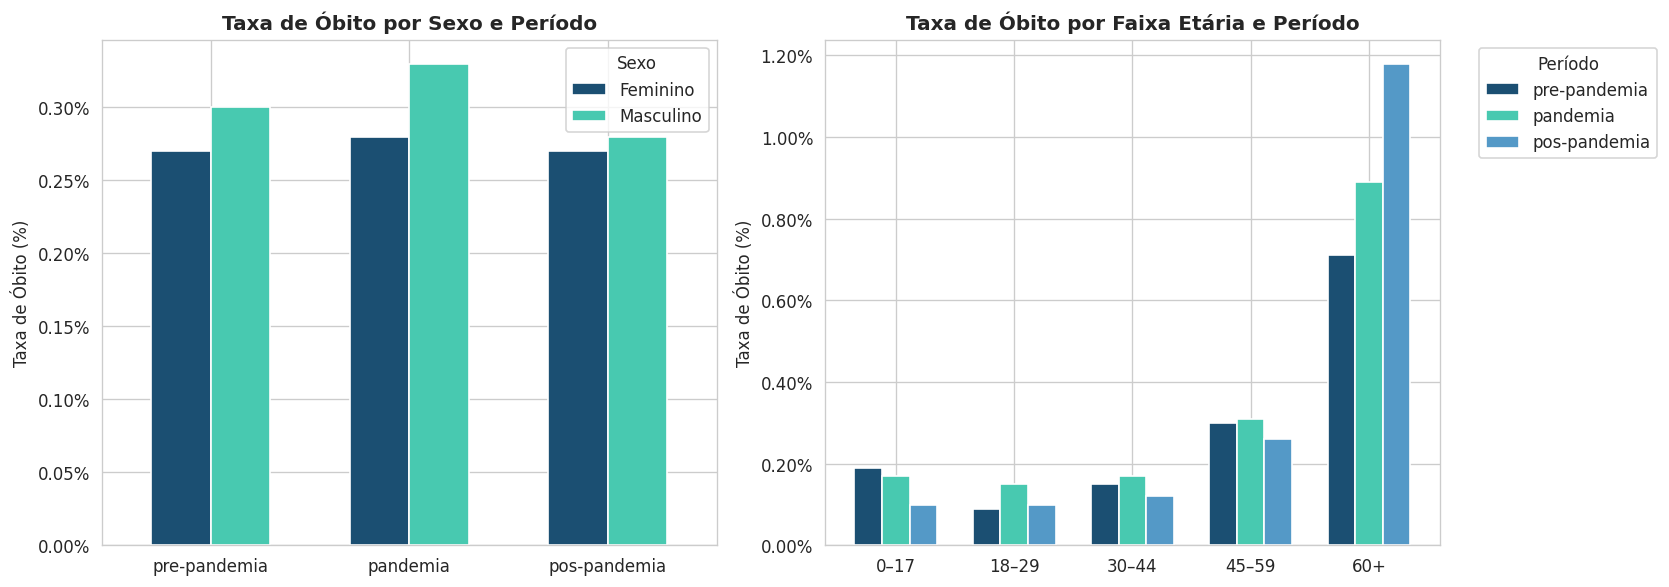

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Óbito por sexo ──
obito_sexo.plot(kind='bar', ax=axes[0],
                color=[COLOR1, COLOR2], edgecolor='white', width=0.6)
axes[0].set_title('Taxa de Óbito por Sexo e Período', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Taxa de Óbito (%)')
axes[0].set_xticklabels(ORDEM_PERIODOS, rotation=0)
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
axes[0].legend(title='Sexo')

# ── Óbito por faixa etária ──
obito_faixa.T.plot(kind='bar', ax=axes[1],
                   color=[PALETTE_PERIODO[p] for p in ORDEM_PERIODOS],
                   edgecolor='white', width=0.7)
axes[1].set_title('Taxa de Óbito por Faixa Etária e Período', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Taxa de Óbito (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
axes[1].legend(title='Período', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()